In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

dejare esto comentad de igual forma para saber que fui haciendo en cada bloque y con eobjetivo..

Aqui solo estamos diciendo con que vamos a trabajar la parte 1

In [2]:
# activos
tickers = ["MELI", "REGN", "B"]

# fechas
train_start = "2024-09-17"
train_end = "2025-09-16"

test_start = "2025-09-17"
test_end = "2026-09-17"

# capital inicial
capital = 1_000_000

# tasa libre de riesgo esta utilizada de acuerdo a Treassury de EEU
rf = 0.036

# dias bursatiles
dias = 252

# parametros del algoritmo genetico
population_size = 100
generations = 200
mutation_rate = 0.20
elite_size = 5

# para obtener los mismos resultados aleatorios
np.random.seed(42)

2. descargar precios y calcular rendimeintos 


In [3]:
# descargamos un dia extra porque yfinance no incluye la fecha "end"
end_download = "2026-09-18"

data = yf.download(
    tickers,
    start=train_start,
    end=end_download,
    auto_adjust=True,
    progress=False
)

# tomamos los precios de cierre ajustados
prices = data["Close"]

# ordenamos las columnas
prices = prices[tickers]

# eliminamos filas con datos faltantes
prices = prices.dropna()

# calculamos rendimientos simples diarios
returns = prices.pct_change().dropna()

returns.head()

Ticker,MELI,REGN,B
Date,,,
2024-09-18,0.013682,-0.006924,-0.020508
2024-09-19,0.003215,0.009993,0.008475
2024-09-20,-0.002678,-0.004486,0.007415
2024-09-23,-0.000532,-0.046331,-0.008341
2024-09-24,0.003981,-0.042125,0.010886


3. Separo Train y test

In [4]:
train = returns.loc[train_start:train_end]

test = returns.loc[test_start:test_end]

print("Observaciones TRAIN:", len(train))
print("Observaciones TEST:", len(test))

print("\nTRAIN:")
print(train.index.min(), "a", train.index.max())

print("\nTEST:")
print(test.index.min(), "a", test.index.max())

Observaciones TRAIN: 249
Observaciones TEST: 252

TRAIN:
2024-09-18 00:00:00 a 2025-09-16 00:00:00

TEST:
2025-09-17 00:00:00 a 2026-09-17 00:00:00


 Funciones financieras, sacamos medias y covarianzas utilizando  TRAIN: 
 

In [6]:
mean_returns = train.mean()
cov_matrix = train.cov()


def portfolio_return(weights):
    
    annual_return = np.dot(weights, mean_returns) * dias
    
    return annual_return


def portfolio_volatility(weights):
    
    variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    
    volatility = np.sqrt(variance) * np.sqrt(dias)
    
    return volatility


def sharpe_ratio(weights):
    
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    
    sharpe = (ret - rf) / vol
    
    return sharpe

In [24]:
# medimos los rendimienot negativos 
def semivariance(weights):
    
    portfolio_returns = np.dot(train, weights)
    
    downside = np.minimum(portfolio_returns, 0)
    
    semi = np.mean(downside ** 2)
    
    return semi

In [32]:
# ALGORITMO GENETICO    
def crear_poblacion():
    
    poblacion = []
    
    for i in range(population_size):
        
        weights = np.random.random(3)
        
        # hacemos que los pesos sumen 1
        weights = weights / weights.sum()
        
        poblacion.append(weights)
    
    return np.array(poblacion)


# seleccion 
def seleccionar(poblacion, fitness):
    
    candidatos = np.random.choice(len(poblacion), 3, replace=False)
    
    mejor = candidatos[np.argmax(fitness[candidatos])]
    
    return poblacion[mejor]

# mezcalmos dos portafolio 
def crossover(padre1, padre2):
    
    alpha = np.random.random()
    
    hijo = alpha * padre1 + (1 - alpha) * padre2
    
    return hijo

# mutacion 
def mutacion(weights):
    
    if np.random.random() < mutation_rate:
        
        cambio = np.random.normal(0, 0.05, 3)
        
        weights = weights + cambio
        
        # no permitimos pesos negativos
        weights = np.clip(weights, 0, 1)
        
        # hacemos que vuelvan a sumar 1
        weights = weights / weights.sum()
    
    return weights

In [30]:
def algoritmo_genetico(fitness_function):
    
    poblacion = crear_poblacion()
    
    history = []
    
    for generation in range(generations):
        
        # calculamos fitness
        fitness = np.array([
            fitness_function(weights)
            for weights in poblacion
        ])
        
        # ordenamos de mejor a peor
        orden = np.argsort(fitness)[::-1]
        
        poblacion = poblacion[orden]
        fitness = fitness[orden]
        
        # guardamos el mejor resultado
        history.append(fitness[0])
        
        # conservamos los mejores
        nueva_poblacion = list(poblacion[:elite_size])
        
        # creamos nuevos individuos
        while len(nueva_poblacion) < population_size:
            
            padre1 = seleccionar(poblacion, fitness)
            padre2 = seleccionar(poblacion, fitness)
            
            hijo = crossover(padre1, padre2)
            hijo = mutacion(hijo)
            
            nueva_poblacion.append(hijo)
        
        poblacion = np.array(nueva_poblacion)
    
    
    # calculamos fitness una ultima vez
    fitness = np.array([
        fitness_function(weights)
        for weights in poblacion
    ])
    
    mejor = poblacion[np.argmax(fitness)]
    
    return mejor, history

In [34]:
# ENCONTAR MAXIMO DE SHARPE 
weights_sharpe, history_sharpe = algoritmo_genetico(
    sharpe_ratio)

print("Pesos Máximo Sharpe:")
print(weights_sharpe)

print("\nSharpe:")
print(sharpe_ratio(weights_sharpe))

for ticker, weight in zip(tickers, weights_sharpe):
    print(ticker, round(weight * 100, 2), "%")


Pesos Máximo Sharpe:
[2.14945536e-01 2.06599055e-15 7.85054464e-01]

Sharpe:
1.2245758338631392
MELI 21.49 %
REGN 0.0 %
B 78.51 %


In [ ]:
#minima semivarianza de acuerdoi a nuestro perfìl "No queremos minimizar el riesgo a costa de obtener cualquier rendimeinto"
equal_weights = np.array([1/3, 1/3, 1/3])

target_return = portfolio_return(equal_weights)

print("Target return:", target_return)



# ahora hacemos nuestro fitness 
def fitness_semivariance(weights):
    
    ret = portfolio_return(weights)
    semi = semivariance(weights)
    
    # penalizamos si no alcanza el rendimiento minimo
    if ret < target_return:
        return -1000
    
    # como el algoritmo maximiza fitness,
    # usamos el negativo de la semivarianza
    return -semi

# ahora si optimizamos 
weights_semi, history_semi = algoritmo_genetico(
    fitness_semivariance
)

print("Pesos Mínima Semivarianza:")

for ticker, weight in zip(tickers, weights_semi):
    print(ticker, round(weight * 100, 2), "%")



Target return: 0.008601719790479674
Pesos Mínima Semivarianza:
MELI 29.75 %
REGN 20.98 %
B 49.28 %


 Si el portafolio no alcanza el rendimeinto minimo exigido , recibe un fitness muy mal 

In [ ]:
#nuestro tres portafolio 
portfolios = {
    "Maximo Sharpe": weights_sharpe,
    "Minima Semivarianza": weights_semi,
    "Equiponderado": equal_weights
}
portfolios 

# YA TENEMOS EXACTAMENTE LAS TRES ESTRATEGIAS QUE QUERIAMOS COMPROBAR 

{'Maximo Sharpe': array([2.14945536e-01, 2.06599055e-15, 7.85054464e-01]),
 'Minima Semivarianza': array([0.29748176, 0.20976271, 0.49275553]),
 'Equiponderado': array([0.33333333, 0.33333333, 0.33333333])}

In [42]:
# convertir pesos a dolares 
for name, weights in portfolios.items():
    
    print("\n", name)
    
    for ticker, weight in zip(tickers, weights):
        
        allocation = weight * capital
        
        print(
            ticker,
            round(weight * 100, 2), "%",
            " = $",
            round(allocation, 2))


 Maximo Sharpe
MELI 21.49 %  = $ 214945.54
REGN 0.0 %  = $ 0.0
B 78.51 %  = $ 785054.46

 Minima Semivarianza
MELI 29.75 %  = $ 297481.76
REGN 20.98 %  = $ 209762.71
B 49.28 %  = $ 492755.53

 Equiponderado
MELI 33.33 %  = $ 333333.33
REGN 33.33 %  = $ 333333.33
B 33.33 %  = $ 333333.33


In [43]:
# es necesario sacar el backtesting 
portfolio_test_returns = pd.DataFrame()

for name, weights in portfolios.items():
    
    portfolio_test_returns[name] = np.dot(test, weights)

    # y calculamos como habra  valido nuestro millon 
    portfolio_values = capital * (
    1 + portfolio_test_returns
).cumprod()

portfolio_values.tail()


,Maximo Sharpe,Minima Semivarianza,Equiponderado
247,1.381495e+06,1.299870e+06,1.251730e+06
248,1.350908e+06,1.286399e+06,1.246961e+06
249,1.346761e+06,1.269401e+06,1.223730e+06
250,1.344752e+06,1.269599e+06,1.224963e+06
251,1.370758e+06,1.288485e+06,1.240507e+06


In [44]:
# funcion para las metricas 
def metricas(returns):
    
    cumulative_return = (1 + returns).prod() - 1
    
    annual_return = returns.mean() * dias
    
    volatility = returns.std() * np.sqrt(dias)
    
    sharpe = (annual_return - rf) / volatility
    
    
    # downside
    downside_returns = np.minimum(returns, 0)
    
    downside_deviation = (
        np.sqrt(np.mean(downside_returns ** 2))
        * np.sqrt(dias)
    )
    
    
    # Sortino con MAR = 0
    sortino = annual_return / downside_deviation
    
    
    # drawdown
    wealth = (1 + returns).cumprod()
    
    running_max = wealth.cummax()
    
    drawdown = wealth / running_max - 1
    
    max_drawdown = drawdown.min()
    
    
    return {
        "Rendimiento": cumulative_return,
        "Rendimiento anual": annual_return,
        "Volatilidad": volatility,
        "Sharpe": sharpe,
        "Downside": downside_deviation,
        "Sortino": sortino,
        "Max Drawdown": max_drawdown
    }

Tabla final 



In [45]:
resultados = []

for name, weights in portfolios.items():
    
    m = metricas(portfolio_test_returns[name])
    
    final_value = portfolio_values[name].iloc[-1]
    
    
    resultados.append({
        
        "Estrategia": name,
        
        "Peso MELI": weights[0],
        "Peso REGN": weights[1],
        "Peso Barrick": weights[2],
        
        "USD MELI": weights[0] * capital,
        "USD REGN": weights[1] * capital,
        "USD Barrick": weights[2] * capital,
        
        **m,
        
        "Capital Final": final_value,
        "Ganancia USD": final_value - capital
    })


resultados = pd.DataFrame(resultados)

resultados

,Estrategia,Peso MELI,Peso REGN,Peso Barrick,USD MELI,USD REGN,USD Barrick,Rendimiento,Rendimiento anual,Volatilidad,Sharpe,Downside,Sortino,Max Drawdown,Capital Final,Ganancia USD
0,Maximo Sharpe,0.214946,2.065991e-15,0.785054,214945.536089,2.065991e-09,785054.463911,0.370758,0.397239,0.404116,0.893900,0.281864,1.409326,-0.295746,1.370758e+06,370757.720530
1,Minima Semivarianza,0.297482,2.097627e-01,0.492756,297481.762808,2.097627e+05,492755.528914,0.288485,0.298912,0.301576,0.871794,0.204742,1.459946,-0.260575,1.288485e+06,288485.397700
2,Equiponderado,0.333333,3.333333e-01,0.333333,333333.333333,3.333333e+05,333333.333333,0.240507,0.250430,0.264615,0.810347,0.176046,1.422523,-0.254061,1.240507e+06,240507.149581


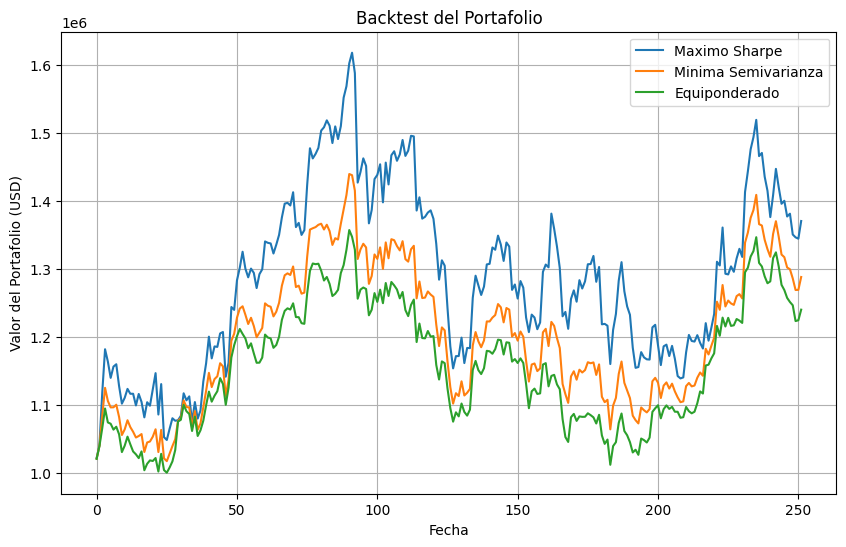

In [46]:
# Garfica del millon de dolares 
plt.figure(figsize=(10, 6))

for name in portfolio_values.columns:
    plt.plot(
        portfolio_values.index,
        portfolio_values[name],
        label=name
    )

plt.title("Backtest del Portafolio")
plt.xlabel("Fecha")
plt.ylabel("Valor del Portafolio (USD)")
plt.legend()
plt.grid()

plt.show()

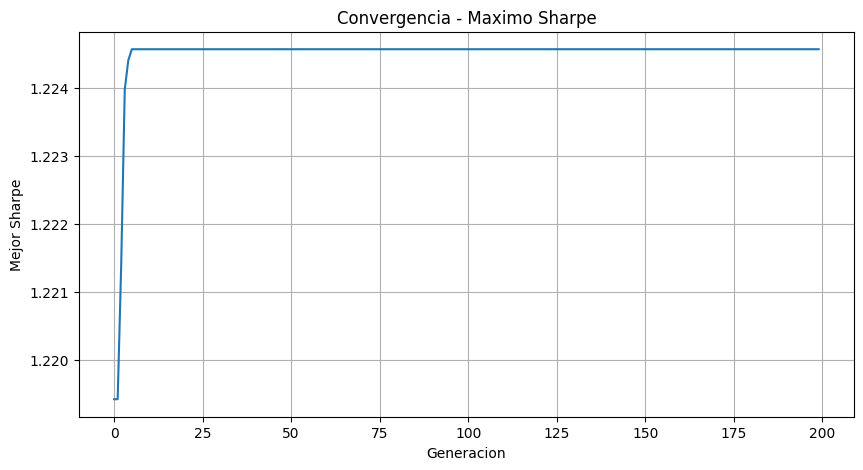

In [47]:
# convergencia del algoritmo genetivo 
plt.figure(figsize=(10, 5))

plt.plot(history_sharpe)

plt.title("Convergencia - Maximo Sharpe")
plt.xlabel("Generacion")
plt.ylabel("Mejor Sharpe")

plt.grid()

plt.show()

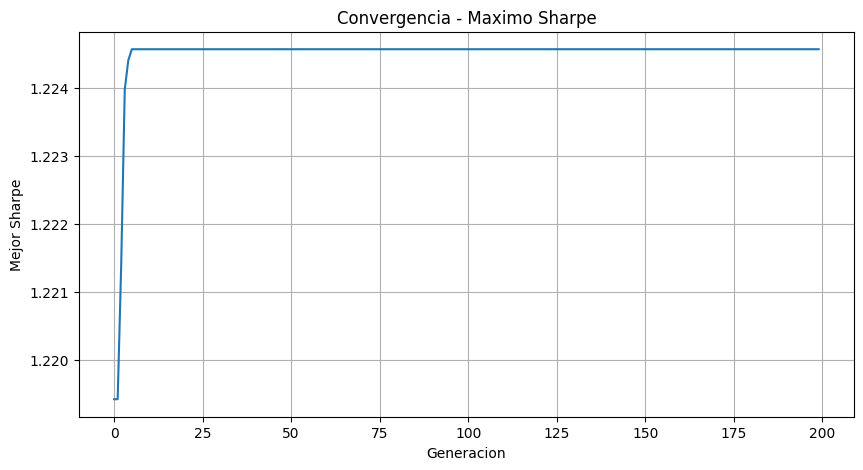

In [48]:
# convergencia de semivarianza 

plt.figure(figsize=(10, 5))

plt.plot(history_sharpe)

plt.title("Convergencia - Maximo Sharpe")
plt.xlabel("Generacion")
plt.ylabel("Mejor Sharpe")

plt.grid()

plt.show()